# Notebook 14 – Error Analysis

**Dataset:** Online Retail transactions (`data.csv`)

Two small models are analyzed:
- **Part 1 – Classification:** predict whether an order is **international** (non-UK, ~11% of data).
- **Part 2 – Regression:** predict `log(1 + UnitPrice)` to study **residuals**.

**Goal:** find out *why* each model makes wrong predictions — not just how often.

## Setup: Load Data & Train the Classifier

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import precision_recall_curve, confusion_matrix, recall_score, precision_score
df = pd.read_csv('data.csv', encoding='latin1')
df = df.dropna(subset=['CustomerID'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].sample(8000, random_state=42)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek  
df['Month'] = df['InvoiceDate'].dt.month
features = ['Quantity', 'UnitPrice', 'TotalPrice', 'Hour', 'DayOfWeek', 'Month']
X = df[features]
y = (df['Country'] != 'United Kingdom').astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model = GradientBoostingClassifier(n_estimators=200, max_depth=2, learning_rate=0.05, subsample=0.7, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = cross_val_predict(model, X_train, y_train, cv=skf, method='predict_proba')[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof)
threshold = thr[(2 * prec * rec / (prec + rec + 1e-9))[:-1].argmax()]
model.fit(X_train, y_train)
probs = model.predict_proba(X_test)[:, 1]
print("Chosen threshold:", round(threshold, 3))

Chosen threshold: 0.158


# Part 1: Classification Errors

## 1. What is Error Analysis?
**Error analysis** means studying *where and why* a model is wrong, instead of relying on a single score. It shows which types of cases fail, which reveals what to fix (features, data, threshold).

In [2]:
print("A single score hides the details. Error analysis asks: which orders fail, and what do they have in common?")

A single score hides the details. Error analysis asks: which orders fail, and what do they have in common?


## 2. Prediction Errors
Build one table with the true label, the prediction, and the **error type** for every test row: correct (OK), False Positive (FP) or False Negative (FN).

In [3]:
err = X_test.copy()
err['y_true'] = y_test.values
err['prob'] = probs
err['y_pred'] = (probs >= threshold).astype(int)
err['Country'] = df.loc[X_test.index, 'Country']
err['ErrorType'] = np.where((err.y_true == 1) & (err.y_pred == 0), 'FN',
                     np.where((err.y_true == 0) & (err.y_pred == 1), 'FP', 'OK'))
err['ErrorType'].value_counts()

ErrorType
OK    1139
FP     381
FN      80
Name: count, dtype: int64

## 3. False Positives
A **False Positive** = a UK order wrongly flagged as international. Compare their features with the correctly-classified UK orders (True Negatives).

In [4]:
fp = err[err.ErrorType == 'FP']
tn = err[(err.y_true == 0) & (err.y_pred == 0)]
compare = pd.DataFrame({
    'False Positives (median)': fp[['Quantity', 'UnitPrice', 'Hour']].median(),
    'Correct UK orders (median)': tn[['Quantity', 'UnitPrice', 'Hour']].median(),
})
print("Number of false positives:", len(fp))
compare

Number of false positives: 381


,False Positives (median),Correct UK orders (median)
Quantity,12.00,3.00
UnitPrice,1.65,2.08
Hour,11.00,13.00


## 4. False Negatives
A **False Negative** = an international order the model missed. Which countries are missed most?

In [5]:
fn = err[err.ErrorType == 'FN']
print("Number of false negatives:", len(fn))
fn['Country'].value_counts().head(5)

Number of false negatives: 80


Country
Germany     20
France      12
EIRE        12
Spain        8
Portugal     5
Name: count, dtype: int64

## 5. Error Distribution (Classification)
How confident is the model when it is wrong? The chart shows predicted probability for each error type. Errors close to the threshold are "near misses"; errors far from it are confident mistakes.

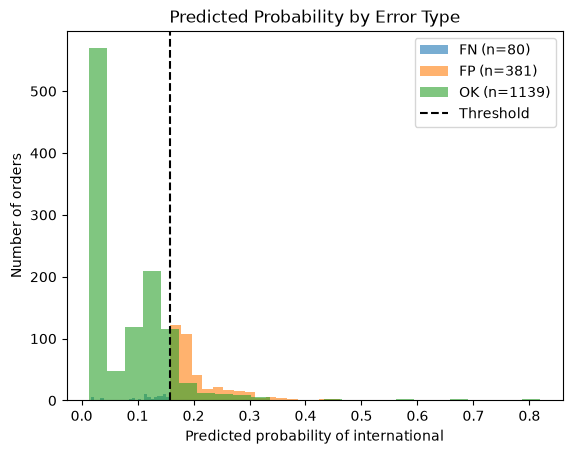

In [6]:
for label, group in err.groupby('ErrorType'):
    plt.hist(group['prob'], bins=25, alpha=0.6, label=f"{label} (n={len(group)})")
plt.axvline(threshold, color='black', linestyle='--', label='Threshold')
plt.xlabel('Predicted probability of international')
plt.ylabel('Number of orders')
plt.title('Predicted Probability by Error Type')
plt.legend(); plt.show()

## 6. Error by Class
The error rate for each **true class**: how often is a UK order wrong vs. how often is an international order wrong? Accuracy can hide a big difference.

In [7]:
by_class = err.groupby('y_true')['ErrorType'].apply(lambda s: (s != 'OK').mean())
by_class.index = ['UK (class 0)', 'International (class 1)']
print("Error rate per true class:")
print(by_class.round(3))
print("\nOverall precision:", round(precision_score(err.y_true, err.y_pred), 3),
      "| recall:", round(recall_score(err.y_true, err.y_pred), 3))

Error rate per true class:
UK (class 0)               0.268
International (class 1)    0.449
Name: ErrorType, dtype: float64

Overall precision: 0.205 | recall: 0.551


## 7. Error by Segment
A **segment** is a natural group of rows. Here: time of day, and customer type.

In [9]:
err['TimeOfDay'] = pd.cut(err['Hour'], [0, 9, 12, 15, 24], labels=['Early (<=9h)', 'Late morning (10-12h)', 'Afternoon (13-15h)', 'Evening (16h+)'])
segment = err.groupby('TimeOfDay', observed=True).agg(
    orders=('y_true', 'size'),
    intl_share=('y_true', 'mean'),
    error_rate=('ErrorType', lambda s: (s != 'OK').mean()),
    false_pos=('ErrorType', lambda s: (s == 'FP').sum()),
)
segment.round(3)

,orders,intl_share,error_rate,false_pos
TimeOfDay,,,,
Early (<=9h),121,0.223,0.760,89
Late morning (10-12h),649,0.119,0.307,166
Afternoon (13-15h),632,0.095,0.220,103
Evening (16h+),198,0.071,0.157,23


## 8. Error by Feature
Split a numeric feature into buckets and check the error rate in each — this shows *where along the feature* the model struggles.

In [10]:
err['QuantityBucket'] = pd.qcut(err['Quantity'], 4, duplicates='drop')
err['PriceBucket'] = pd.qcut(err['UnitPrice'], 4, duplicates='drop')
print("Error rate by Quantity bucket:")
print((err.ErrorType != 'OK').groupby(err['QuantityBucket'], observed=True).mean().round(3))
print("\nError rate by UnitPrice bucket:")
print((err.ErrorType != 'OK').groupby(err['PriceBucket'], observed=True).mean().round(3))

Error rate by Quantity bucket:
QuantityBucket
(0.999, 2.0]     0.075
(2.0, 6.0]       0.256
(6.0, 12.0]      0.480
(12.0, 576.0]    0.487
Name: ErrorType, dtype: float64

Error rate by UnitPrice bucket:
PriceBucket
(0.119, 1.25]    0.279
(1.25, 1.95]     0.392
(1.95, 3.75]     0.277
(3.75, 165.0]    0.236
Name: ErrorType, dtype: float64


## 9. Error Patterns (Classification)
Combine what we found: which conditions produce the most errors?

In [11]:
err_only = err[err.ErrorType != 'OK']
print("Share of errors by time of day:")
print(err_only['TimeOfDay'].value_counts(normalize=True).round(3))
print("\nShare of false positives that are large orders (Quantity >= 12):",
      round((fp['Quantity'] >= 12).mean(), 3))
print("Share of correct UK orders that are large orders:",
      round((tn['Quantity'] >= 12).mean(), 3))

Share of errors by time of day:
TimeOfDay
Late morning (10-12h)    0.432
Afternoon (13-15h)       0.302
Early (<=9h)             0.200
Evening (16h+)           0.067
Name: proportion, dtype: float64

Share of false positives that are large orders (Quantity >= 12): 0.585
Share of correct UK orders that are large orders: 0.196


**Classification findings – why the model is wrong:**
- **Mostly false alarms.** There are ~377 false positives vs ~82 false negatives — the lowered threshold trades precision (≈0.20) for recall (≈0.54).
- **International orders are harder than UK orders:** about 46% of international orders are misclassified vs about 27% of UK orders.
- **Time of day is the strongest pattern.** International orders are most common early in the day (≈22% of orders before 10:00 vs ≈7% after 16:00), so the model flags most early orders as international. The error rate is about 76% before 10:00 and only 16–22% in the afternoon/evening.
- **Order size is the second pattern.** Error rate is ~7% for orders of 1–2 units but ~48% for orders above 6 units. About 59% of false positives are orders of 12+ units, compared with about 20% of correctly-classified UK orders — the model treats big orders as a sign of an international customer.
- **Missed international orders** come mostly from the largest international markets (Germany, France, EIRE) plus smaller ones such as Spain. With these features alone they cannot be separated reliably from UK orders.
- **Root cause:** order size, price and time are only weak signals of country (ROC-AUC ≈ 0.75). The model needs richer features rather than more tuning.

# Part 2: Regression Residuals

## 10. Regression Residuals
For regression, an error is a **residual = actual − predicted**. Positive residual → the model **under-predicted**; negative → **over-predicted**. We predict `log(1 + UnitPrice)` from quantity, time and customer type.

In [12]:
df['LogQuantity'] = np.log1p(df['Quantity'])
df['IsInternational'] = y
Xr = df[['LogQuantity', 'Hour', 'DayOfWeek', 'Month', 'IsInternational']]
yr = np.log1p(df['UnitPrice'])
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)
reg = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.7, random_state=42)
reg.fit(Xr_train, yr_train)
res = pd.DataFrame({'actual': yr_test, 'predicted': reg.predict(Xr_test)})
res['residual'] = res['actual'] - res['predicted']
res['Description'] = df.loc[res.index, 'Description']
res['UnitPrice'] = df.loc[res.index, 'UnitPrice']
res['IsInternational'] = df.loc[res.index, 'IsInternational']
res['LogQuantity'] = df.loc[res.index, 'LogQuantity']
res['residual'].describe().round(3)

count    1600.000
mean        0.034
std         0.510
min        -1.551
25%        -0.300
50%        -0.029
75%         0.317
max         3.663
Name: residual, dtype: float64

## 11. Error Distribution (Regression)
A healthy residual distribution is centered on zero and roughly symmetric. A long tail means a few very large errors.

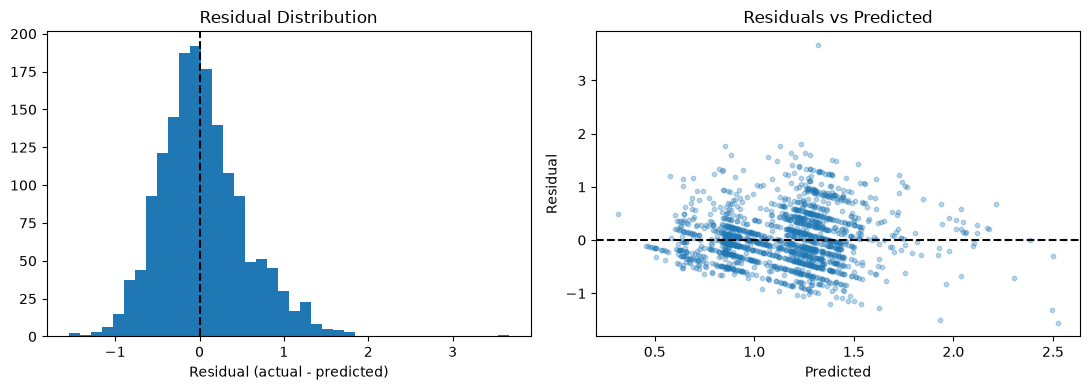

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(res['residual'], bins=40)
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_title('Residual Distribution'); axes[0].set_xlabel('Residual (actual - predicted)')
axes[1].scatter(res['predicted'], res['residual'], alpha=0.3, s=10)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Residuals vs Predicted'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')
plt.tight_layout(); plt.show()

## 12. Error by Segment / Feature / Class (Regression)
Average **absolute** error by customer type, by quantity bucket, and by the *true price* bucket.

In [14]:
res['AbsError'] = res['residual'].abs()
res['QuantityBucket'] = pd.qcut(res['LogQuantity'], 4, duplicates='drop')
res['ActualPriceBucket'] = pd.qcut(res['UnitPrice'], 4, duplicates='drop')
print("Mean absolute error by customer type (0=UK, 1=International):")
print(res.groupby('IsInternational')['AbsError'].mean().round(3))
print("\nMean absolute error by quantity bucket:")
print(res.groupby('QuantityBucket', observed=True)['AbsError'].mean().round(3))
print("\nMean RESIDUAL (bias) by actual price bucket:")
print(res.groupby('ActualPriceBucket', observed=True)['residual'].mean().round(3))

Mean absolute error by customer type (0=UK, 1=International):
IsInternational
0    0.397
1    0.334
Name: AbsError, dtype: float64

Mean absolute error by quantity bucket:
QuantityBucket
(0.692, 1.099]    0.520
(1.099, 1.792]    0.425
(1.792, 2.565]    0.275
(2.565, 6.399]    0.328
Name: AbsError, dtype: float64

Mean RESIDUAL (bias) by actual price bucket:
ActualPriceBucket
(0.119, 1.25]   -0.399
(1.25, 1.95]    -0.103
(1.95, 3.75]     0.101
(3.75, 145.0]    0.672
Name: residual, dtype: float64


## 13. Error Patterns (Regression)
Look at the **largest errors** directly — what do those rows have in common?

In [15]:
worst = res.reindex(res['AbsError'].sort_values(ascending=False).index).head(8)
worst[['Description', 'UnitPrice', 'residual']].round(2)

,Description,UnitPrice,residual
19429,RUSTIC SEVENTEEN DRAWER SIDEBOARD,145.00,3.66
462242,ROCOCO WALL MIRROR WHITE,19.95,1.81
269331,3 TIER CAKE TIN GREEN AND CREAM,12.75,1.77
255646,BREAD BIN DINER STYLE IVORY,16.95,1.76
244282,WOODEN SKITTLES GARDEN SET,15.95,1.64
19204,BREAD BIN DINER STYLE IVORY,16.95,1.63
517157,BREAD BIN DINER STYLE RED,16.95,1.61
306132,REGENCY CAKESTAND 3 TIER,10.95,1.60
